In [1]:
import os
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import random
import copy

2026-02-18 11:33:57.737965: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-18 11:33:57.938345: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-18 11:33:58.887512: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/qduong/Projects/MusicEditLearning/.venv/lib/python3.12/site-packages/keras/src/export

In [2]:
test_path = "data/test/*.tfrecord"
train_path = "data/train/*.tfrecord"
val_path = "data/validation/*.tfrecord"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def parse_seq_example(example_proto):
    # Define how to parse
    context_features = {
    }

    sequence_features = {
        "pitch_seq": tf.io.VarLenFeature(dtype=tf.int64),
    }
    _, sequence = tf.io.parse_single_sequence_example(
        example_proto,
        context_features=context_features,
        sequence_features=sequence_features
    )
    pitch_seq = tf.sparse.to_dense(sequence["pitch_seq"])
    pitch_seq = tf.reshape(pitch_seq, [-1])
    return pitch_seq

# Create dataset
# dataset = tf.data.TFRecordDataset(tf.io.gfile.glob(tfrecord_path))
# dataset = dataset.map(parse_seq_example)





/home/qduong/Projects/MusicEditLearning/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
# Inspect first example
# for seq in dataset.take(1):
#     print(seq.numpy())

In [3]:
def pitch_seq_to_notes(pitch_seq):
    notes = []
    i = 0
    while i < len(pitch_seq):
        token = pitch_seq[i]
        if token == 128:
            # hold token without a preceding note — skip
            i += 1
            continue
        if token == 129:
            # rest — skip or treat as durationless rest
            i += 1
            continue

        # Otherwise, this is a real note onset
        pitch = int(token)
        duration = 1
        j = i + 1
        # Count holds
        while j < len(pitch_seq) and pitch_seq[j] == 128:
            duration += 1
            j += 1

        notes.append((pitch, duration))
        i = j

    return notes


In [4]:
# notes = pitch_seq_to_notes(seq.numpy())
# print(notes)

In [4]:
PITCH_MIN = 21
PITCH_MAX = 108
DURATIONS = [1, 2, 3, 4, 6, 8] 

SPECIAL_TOKENS = ["<PAD>", "<BOS>", "<EOS>"]

pitch_tokens = [f"P{p}" for p in range(PITCH_MIN, PITCH_MAX + 1)]
duration_tokens = [f"D{d}" for d in DURATIONS]

vocab = SPECIAL_TOKENS + pitch_tokens + duration_tokens

token_to_id = {tok: i for i, tok in enumerate(vocab)}
id_to_token = {i: tok for tok, i in token_to_id.items()}

PAD_ID = token_to_id["<PAD>"]
BOS_ID = token_to_id["<BOS>"]
EOS_ID = token_to_id["<EOS>"]



In [5]:
def melody_is_valid(notes):
    return all(d in DURATIONS for _, d in notes)


def notes_to_tokens(notes, edited_note_indices=None):
    tokens = [BOS_ID]
    mask = [0]

    for i, (pitch, dur) in enumerate(notes):
        tokens.append(token_to_id[f"P{pitch}"])
        tokens.append(token_to_id[f"D{dur}"])

        is_edited = edited_note_indices and i in edited_note_indices
        mask.extend([1 if is_edited else 0, 1 if is_edited else 0])

    tokens.append(EOS_ID)
    mask.append(0)
    return tokens, mask



EDIT_TYPES = ["replace_pitch", "change_duration", "delete_note", "insert_note"]

def sample_edit_type():
    """Samples an edit type from EDIT_TYPES."""
    # p=[0.4, 0.2, 0.2, 0.2]
    return np.random.choice(EDIT_TYPES, p=[0.4, 0.3, 0.15, 0.15])

def sample_position(melody, edit_type):
    """Samples a valid position for a given edit type."""
    if edit_type == "insert_note":
        # Can insert at the end
        return random.randint(0, len(melody))

    return random.randint(0, len(melody) - 1)

def sample_duration(exclude_duration):
    """Samples a duration from DURATIONS, excluding exclude_duration."""
    new_durations = [d for d in DURATIONS if d != exclude_duration]
    if not new_durations:
        return exclude_duration
    return random.choice(new_durations)

def sample_insert_note():
    """Samples a random note to insert."""
    pitch = random.randint(PITCH_MIN, PITCH_MAX)
    duration = random.choice(DURATIONS)
    return (pitch, duration)

def simulate_edits(melody, max_edits=5):
    melody_corrupt = copy.deepcopy(melody)
    edit_script = []

    n_edits = random.randint(1, max_edits)

    for _ in range(n_edits):
        edit_type = sample_edit_type()

        if edit_type == "insert_note":
            t = sample_position(melody_corrupt, edit_type)
            note = sample_insert_note()
            melody_corrupt.insert(t, note)
            edit_script.append(("delete_note", t))
        elif len(melody_corrupt) == 0: # No other edits possible on empty melody
            continue
        else:
            t = sample_position(melody_corrupt, edit_type)
            if edit_type == "replace_pitch":
                old_p, d = melody_corrupt[t]
                # Make sure new pitch is different and within bounds
                new_p = old_p
                while new_p == old_p:
                    new_p = old_p + random.choice([-2, -1, 1, 2])
                    new_p = max(PITCH_MIN, min(PITCH_MAX, new_p))

                melody_corrupt[t] = (new_p, d)
                edit_script.append(("replace_pitch", t, old_p))

            elif edit_type == "change_duration":
                p, old_d = melody_corrupt[t]
                new_d = sample_duration(old_d)
                melody_corrupt[t] = (p, new_d)
                edit_script.append(("change_duration", t, old_d))

            elif edit_type == "delete_note":
                note = melody_corrupt.pop(t)
                edit_script.append(("insert_note", t, note))

    return melody_corrupt, edit_script




In [6]:


def collate_fn(batch):
    corrupted, clean, masks, edit_scripts = zip(*batch)

    corrupted = pad_sequence(corrupted, batch_first=True, padding_value=PAD_ID)
    clean = pad_sequence(clean, batch_first=True, padding_value=PAD_ID)
    masks = pad_sequence(masks, batch_first=True, padding_value=0)

    # print((corrupted == PAD_ID).sum())
    # print((clean == PAD_ID).sum())

    return corrupted, clean, masks, edit_scripts


class MelodyDataset(Dataset):
    def __init__(self, tfrecord_path):
        self.dataset = tf.data.TFRecordDataset(tf.io.gfile.glob(tfrecord_path))
        self.dataset = self.dataset.map(parse_seq_example)
        self.samples = []

        for pitch_seq in self.dataset:
            notes = pitch_seq_to_notes(pitch_seq.numpy())
            if len(notes) > 0 and melody_is_valid(notes):
                self.samples.append(notes)

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        original_notes = self.samples[idx]
        corrupted_notes, edit_script = simulate_edits(original_notes)
        
        edited_positions = {e[1] for e in edit_script if len(e) > 1}

        corrupted_tokens, edit_mask = notes_to_tokens(corrupted_notes, edited_positions)
        original_tokens, _ = notes_to_tokens(original_notes)

        
        return (
            torch.tensor(corrupted_tokens, dtype=torch.long),
            torch.tensor(original_tokens, dtype=torch.long),
            torch.tensor(edit_mask, dtype=torch.long),
            edit_script
        )

In [7]:
# train_dataset = MelodyDataset(train_path)
val_dataset = MelodyDataset(val_path)
test_dataset = MelodyDataset(test_path)

# print(f"Train Dataset size: {len(train_dataset)}")
print(f"Val Dataset size: {len(val_dataset)}")
print(f"Test Dataset size: {len(test_dataset)}")

2026-02-18 11:34:26.888190: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
2026-02-18 11:34:26.888214: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-02-18 11:34:26.888217: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: gpu
2026-02-18 11:34:26.888219: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] hostname: gpu
2026-02-18 11:34:26.888266: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] libcuda reported version is: 570.211.1
2026-02-18 11:34:26.888280: I external/local_xla/xla/stream_executor/cuda/cuda_diagno

Val Dataset size: 44984
Test Dataset size: 13957


2026-02-18 11:34:30.596261: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
test_dataset[3]

(tensor([ 1, 58, 92, 56, 92, 54, 92, 53, 92, 58, 94, 58, 94, 58, 96, 54, 94, 54,
         94, 56, 92, 54, 92, 53, 92, 51, 92, 68, 95, 51, 94, 51, 94, 53, 92, 51,
         92, 49, 92, 48, 92, 56, 94, 56, 94,  2]),
 tensor([ 1, 58, 92, 56, 92, 54, 92, 53, 92, 58, 94, 58, 94, 58, 96, 54, 94, 54,
         94, 56, 92, 54, 92, 53, 92, 51, 92, 51, 94, 51, 94, 53, 92, 51, 92, 49,
         92, 48, 92, 56, 94, 56, 94,  2]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 [('delete_note', 13)])

In [ ]:
# implement training pipeline here

In [8]:


# Create DataLoader
batch_size = 32
# train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# Example of how to use the dataloader
# for corrupted_batch, clean_batch, masks_batch, edit_script_batch in train_dataloader:
#    print(f"Corrupted batch shape: {corrupted_batch.shape}")
#    print(f"Clean batch shape: {clean_batch.shape}")
#    print(f"Masks batch shape: {masks_batch.shape}")
#    print(f"Edit script batch (first item): {edit_script_batch[0]}")
#    break

In [9]:
def causal_mask(size, device):
    return torch.triu(
        torch.ones(size, size, device=device), diagonal=1
    ).bool()


class MelodyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=4, n_layers=4):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_embed = nn.Embedding(512, d_model)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=n_heads,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, n_layers)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)

        mask = causal_mask(T, x.device)

        x = self.embed(x) + self.pos_embed(pos)
        x = self.decoder(x, x, tgt_mask=mask)
        return self.fc(x)

In [10]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
model = MelodyTransformer(vocab_size=len(vocab), d_model=256, n_heads=4, n_layers=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [11]:
baseline_loss = defaultdict(list)

def train_baseline(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    device=device,
    epochs=10,
    patience=5,
    min_improvement=1e-3
):
    """
    Train baseline model with early stopping to prevent overfitting.
    
    Args:
        model: The model to train
        train_dataloader: Training data loader
        val_dataloader: Validation data loader
        optimizer: Optimizer
        device: Device to train on
        epochs: Maximum number of epochs
        patience: Number of epochs with no improvement before stopping
        min_improvement: Minimum improvement threshold for validation loss
    """
    print(f"Training on device: {device}")
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
    
    # Early stopping variables
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for corrupted, clean, _, _ in train_dataloader:
            corrupted = corrupted.to(device)
            clean = clean.to(device)

            # Teacher forcing
            inputs = corrupted[:, :-1]
            targets = clean[:, 1:]

            T = min(inputs.size(1), targets.size(1))

            inputs = inputs[:, :T].to(device)
            targets = targets[:, :T].to(device)

            logits = model(inputs)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                targets.reshape(-1)
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_dataloader)
        print(f"[Baseline] Epoch {epoch+1}: loss = {avg_loss:.4f}")

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for corrupted, clean, _, _ in val_dataloader:
                corrupted = corrupted.to(device)
                clean = clean.to(device)

                inputs = corrupted[:, :-1]
                targets = clean[:, 1:]

                T = min(inputs.size(1), targets.size(1))

                inputs = inputs[:, :T]
                targets = targets[:, :T]

                logits = model(inputs)

                loss = criterion(
                    logits.reshape(-1, logits.size(-1)),
                    targets.reshape(-1)
                )

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        print(f"[Validation] Epoch {epoch+1}: loss = {avg_val_loss:.4f}")
        
        baseline_loss['train'].append(avg_loss)
        baseline_loss['val'].append(avg_val_loss)
        
        # Early stopping logic
        if best_val_loss - avg_val_loss > min_improvement:
            # Significant improvement detected
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            print(f"Validation loss improved to {avg_val_loss:.4f}")
        else:
            # No significant improvement
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            
            if patience_counter >= patience:
                print(f"\nEarly stopping triggered! Validation loss did not improve for {patience} epochs.")
                print(f"Best validation loss: {best_val_loss:.4f}")
                
                # Restore best model
                if best_model_state is not None:
                    model.load_state_dict(best_model_state)
                    print("Restored best model weights.")
                break


In [12]:
batch = next(iter(test_dataloader))
print(batch[0].shape, batch[1].shape)


torch.Size([32, 104]) torch.Size([32, 106])


In [ ]:
# Save trained model
# torch.save(model.state_dict(), os.path.join("models", "baseline.pth"))

# load saved model
# model.load_state_dict(torch.load(os.path.join("models", "baseline.pth")))

In [12]:
train_baseline(model, val_dataloader, test_dataloader, optimizer, epochs=50, patience=5, min_improvement=1e-3)

Training on device: cuda


[Baseline] Epoch 1: loss = 0.9399
[Validation] Epoch 1: loss = 0.5948
Validation loss improved to 0.5948
[Baseline] Epoch 2: loss = 0.5881
[Validation] Epoch 2: loss = 0.5541
Validation loss improved to 0.5541
[Baseline] Epoch 3: loss = 0.5491
[Validation] Epoch 3: loss = 0.5389
Validation loss improved to 0.5389
[Baseline] Epoch 4: loss = 0.5344
[Validation] Epoch 4: loss = 0.5136
Validation loss improved to 0.5136
[Baseline] Epoch 5: loss = 0.5173
[Validation] Epoch 5: loss = 0.5001
Validation loss improved to 0.5001
[Baseline] Epoch 6: loss = 0.4990
[Validation] Epoch 6: loss = 0.4768
Validation loss improved to 0.4768
[Baseline] Epoch 7: loss = 0.4864
[Validation] Epoch 7: loss = 0.4700
Validation loss improved to 0.4700
[Baseline] Epoch 8: loss = 0.4774
[Validation] Epoch 8: loss = 0.4641
Validation loss improved to 0.4641
[Baseline] Epoch 9: loss = 0.4716
[Validation] Epoch 9: loss = 0.4600
Validation loss improved to 0.4600
[Baseline] Epoch 10: loss = 0.4666
[Validation] Epoch 1

In [ ]:
# train_baseline(model, val_dataloader, test_dataloader, optimizer, epochs=10)

In [11]:



def tokens_to_notes(tokens, id_to_token):
    """
    tokens: List[int]
    returns: List[(pitch, duration)]
    """
    notes = []
    i = 0

    while i < len(tokens):
        tok = id_to_token[tokens[i]]

        if tok == "<BOS>" or tok == "<EOS>" or tok == "<PAD>":
            i += 1
            continue

        if tok.startswith("P"):
            pitch = int(tok[1:])
            if i + 1 < len(tokens):
                dur_tok = id_to_token[tokens[i + 1]]
                if dur_tok.startswith("D"):
                    duration = int(dur_tok[1:])
                    notes.append((pitch, duration))
                    i += 2
                else:
                    i += 1
            else:
                i += 1
        else:
            i += 1

    return notes

INSERT_COST = 1
DELETE_COST = 1

def note_replace_cost(n1, n2):
    """
    n1, n2: (pitch, duration)
    """
    cost = 0
    if n1[0] != n2[0]:
        cost += 1  # pitch change
    if n1[1] != n2[1]:
        cost += 1  # duration change
    return cost


def minimal_edit_distance(pred_notes, ref_notes):
    """
    pred_notes: List[(pitch, duration)]
    ref_notes:  List[(pitch, duration)]
    returns: total_cost, edit_counts
    """

    N = len(pred_notes)
    M = len(ref_notes)

    # DP table
    dp = [[0] * (M + 1) for _ in range(N + 1)]

    # Initialize
    for i in range(1, N + 1):
        dp[i][0] = i * DELETE_COST
    for j in range(1, M + 1):
        dp[0][j] = j * INSERT_COST

    # Fill table
    for i in range(1, N + 1):
        for j in range(1, M + 1):
            delete = dp[i - 1][j] + DELETE_COST
            insert = dp[i][j - 1] + INSERT_COST
            replace = dp[i - 1][j - 1] + note_replace_cost(
                pred_notes[i - 1],
                ref_notes[j - 1]
            )
            dp[i][j] = min(delete, insert, replace)

    # Backtrace for edit statistics
    i, j = N, M
    edits = {
        "insert": 0,
        "delete": 0,
        "replace_pitch": 0,
        "replace_duration": 0
    }

    while i > 0 or j > 0:
        current = dp[i][j]

        if i > 0 and current == dp[i - 1][j] + DELETE_COST:
            edits["delete"] += 1
            i -= 1

        elif j > 0 and current == dp[i][j - 1] + INSERT_COST:
            edits["insert"] += 1
            j -= 1

        else:
            # replace or match
            p, d = pred_notes[i - 1]
            rp, rd = ref_notes[j - 1]

            if p != rp:
                edits["replace_pitch"] += 1
            if d != rd:
                edits["replace_duration"] += 1

            i -= 1
            j -= 1

    return dp[N][M], edits



def paired_edit_improvement(baseline_costs: np.ndarray, editaware_costs: np.ndarray):
    """
    Args:
        baseline_costs: list of (total_cost, cost_per_note) tuples
        editaware_costs: list of (total_cost, cost_per_note) tuples

    Returns:
        dict of paired statistics
    """
    deltas = []

    baseline_sample_costs = baseline_costs[:, 0]
    editaware_sample_costs = editaware_costs[:, 0]
    deltas = baseline_sample_costs - editaware_sample_costs

    stats = {
        "mean_delta": float(deltas.mean()),
        "median_delta": float(np.median(deltas)),
        "std_delta": float(deltas.std()),
        "pct_improved": float((deltas > 0).mean() * 100),
        "pct_worse": float((deltas < 0).mean() * 100),
        "pct_equal": float((deltas == 0).mean() * 100),
        "baseline_mean_cost": float(np.mean(baseline_costs)),
        "editaware_mean_cost": float(np.mean(editaware_costs)),
    }

    return stats


def compare_cost_per_note(baseline_costs: np.ndarray, editaware_costs: np.ndarray):
    baseline_norm = baseline_costs[:, 1]
    editaware_norm = editaware_costs[:, 1]
    deltas = baseline_norm - editaware_norm

    return {
        "baseline_mean": float(baseline_norm.mean()),
        "editaware_mean": float(editaware_norm.mean()),
        "mean_delta": float(deltas.mean()),
        "median_delta": float(np.median(deltas)),
        "pct_improved": float((deltas > 0).mean() * 100),
    }

def calculate_edit_cost(pred_tokens, ref_tokens):
    """
    pred_tokens: List[List[(pitch, duration)]]
    ref_tokens:  List[List[(pitch, duration)]]
    returns: total_cost
    """
    total_cost = 0

    for p, r in zip(pred_tokens, ref_tokens):
        pred_notes = tokens_to_notes(p, id_to_token)
        ref_notes = tokens_to_notes(r, id_to_token)

        cost, _ = minimal_edit_distance(pred_notes, ref_notes)
        # costs_per_note = cost / max(len(ref_notes), 1)
        total_cost += cost

    return total_cost


def evaluate_model(model, dataloader):
    model.eval()
    total_cost = 0
    stats = defaultdict(int)
    sample_costs = []

    for corrupted, clean, _, _ in dataloader:
        corrupted = corrupted.to(device)
        clean = clean.to(device)

        with torch.no_grad():
            # Teacher forcing
            inputs = corrupted[:, :-1]
            targets = clean[:, 1:]

            T = min(inputs.size(1), targets.size(1))

            inputs = inputs[:, :T]
            targets = targets[:, :T]

            logits = model(inputs)
            pred_tokens = torch.argmax(logits, dim=-1).cpu().numpy()
            ref_tokens = targets.cpu().numpy()

            # print(ref_tokens.shape, pred_tokens.shape)
            # print(inputs.shape, pred_tokens.shape, len(pred_notes), len(ref_notes))

            for p, r in zip(pred_tokens, ref_tokens):
                pred_notes = tokens_to_notes(p, id_to_token)
                ref_notes = tokens_to_notes(r, id_to_token)
                # print(f"Predicted: {p}, Reference: {r}")
                cost, edit_counts = minimal_edit_distance(pred_notes, ref_notes)
                costs_per_note = cost / max(len(ref_notes), 1)
                sample_costs.append([cost, costs_per_note])

                total_cost += cost

                for k, v in edit_counts.items():
                    stats[k] += v

    return total_cost, stats, np.array(sample_costs)

In [17]:
baseline_total_cost, baseline_stats, baseline_sample_costs = evaluate_model(model, test_dataloader)
print(f"Total edit cost on training set: {baseline_total_cost}")
print(f"Edit statistics: {dict(baseline_stats)}")



Total edit cost on training set: 48836
Edit statistics: {'insert': 9273, 'delete': 6566, 'replace_pitch': 22829, 'replace_duration': 10168}


In [18]:


def edit_weighted_loss(
    logits,
    targets,
    edit_mask,
    pad_id,
    alpha=1.0
):
    """
    logits: (B, T, V)
    targets: (B, T)
    edit_mask: (B, T), 0 or 1
    """

    B, T, V = logits.shape

    # Token-level CE
    ce = F.cross_entropy(
        logits.reshape(-1, V),
        targets.reshape(-1),
        ignore_index=pad_id,
        reduction="none"
    ).view(B, T)

    # Weight edited positions
    weights = 1.0 + alpha * edit_mask.float()

    # Mask out PAD positions explicitly
    valid = (targets != pad_id).float()

    loss = (ce * weights * valid).sum() / valid.sum()
    return loss

edit_aware_loss = defaultdict(list)

def train_edit_aware(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    device=device,
    alpha=1.0,
    epochs=10,
    patience=5,
    min_improvement=1e-3
):

    # Early stopping variables
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        total_loss = 0.0
        model.train()

        for corrupted, clean, edit_mask, _ in train_dataloader:
            corrupted = corrupted.to(device)
            clean = clean.to(device)
            edit_mask = edit_mask.to(device)

            inputs = corrupted[:, :-1]
            targets = clean[:, 1:]
            mask = edit_mask[:, 1:]

            T = min(inputs.size(1), targets.size(1), mask.size(1))

            inputs = inputs[:, :T]
            targets = targets[:, :T]
            mask = mask[:, :T]

            logits = model(inputs)

            loss = edit_weighted_loss(
                logits,
                targets,
                mask,
                pad_id=PAD_ID,
                alpha=alpha
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_dataloader)
        print(f"[Edit-aware α={alpha}] Epoch {epoch+1}: loss = {avg_loss:.4f}")

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for corrupted, clean, edit_mask, _ in val_dataloader:
                corrupted = corrupted.to(device)
                clean = clean.to(device)
                edit_mask = edit_mask.to(device)

                inputs = corrupted[:, :-1]
                targets = clean[:, 1:]
                mask = edit_mask[:, 1:]

                T = min(inputs.size(1), targets.size(1), mask.size(1))

                inputs = inputs[:, :T]
                targets = targets[:, :T]
                mask = mask[:, :T]

                logits = model(inputs)

                loss = edit_weighted_loss(
                    logits,
                    targets,
                    mask,
                    pad_id=PAD_ID,
                    alpha=alpha
                )

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        print(f"[Validation] Epoch {epoch+1}: loss = {avg_val_loss:.4f}")

        edit_aware_loss['train'].append(avg_loss)
        edit_aware_loss['val'].append(avg_val_loss)

                # Early stopping logic
        if best_val_loss - avg_val_loss > min_improvement:
            # Significant improvement detected
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            print(f"Validation loss improved to {avg_val_loss:.4f}")
        else:
            # No significant improvement
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            
            if patience_counter >= patience:
                print(f"\nEarly stopping triggered! Validation loss did not improve for {patience} epochs.")
                print(f"Best validation loss: {best_val_loss:.4f}")
                
                # Restore best model
                if best_model_state is not None:
                    model.load_state_dict(best_model_state)
                    print("Restored best model weights.")
                break


In [26]:
edit_aware_model = MelodyTransformer(vocab_size=len(vocab), d_model=256, n_heads=4, n_layers=4).to(device)
edit_are_optimizer = torch.optim.Adam(edit_aware_model.parameters(), lr=0.0001)

In [27]:
train_edit_aware(edit_aware_model, val_dataloader, test_dataloader, edit_are_optimizer, alpha=0, epochs=100, patience=5, min_improvement=1e-4)

[Edit-aware α=0] Epoch 1: loss = 0.9470
[Validation] Epoch 1: loss = 0.5969
Validation loss improved to 0.5969
[Edit-aware α=0] Epoch 2: loss = 0.5862
[Validation] Epoch 2: loss = 0.5540
Validation loss improved to 0.5540
[Edit-aware α=0] Epoch 3: loss = 0.5512
[Validation] Epoch 3: loss = 0.5279
Validation loss improved to 0.5279
[Edit-aware α=0] Epoch 4: loss = 0.5311
[Validation] Epoch 4: loss = 0.5095
Validation loss improved to 0.5095
[Edit-aware α=0] Epoch 5: loss = 0.5124
[Validation] Epoch 5: loss = 0.4853
Validation loss improved to 0.4853
[Edit-aware α=0] Epoch 6: loss = 0.4938
[Validation] Epoch 6: loss = 0.4745
Validation loss improved to 0.4745
[Edit-aware α=0] Epoch 7: loss = 0.4887
[Validation] Epoch 7: loss = 0.4639
Validation loss improved to 0.4639
[Edit-aware α=0] Epoch 8: loss = 0.4768
[Validation] Epoch 8: loss = 0.4609
Validation loss improved to 0.4609
[Edit-aware α=0] Epoch 9: loss = 0.4699
[Validation] Epoch 9: loss = 0.4561
Validation loss improved to 0.4561
[

In [21]:
# Impelemnt the visualization of training and validation loss here
def visualize_loss(loss_dict):


    epochs = range(1, len(loss_dict['train']) + 1)

    plt.plot(epochs, loss_dict['train'], label='Training Loss')
    plt.plot(epochs, loss_dict['val'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.legend()
    plt.show()


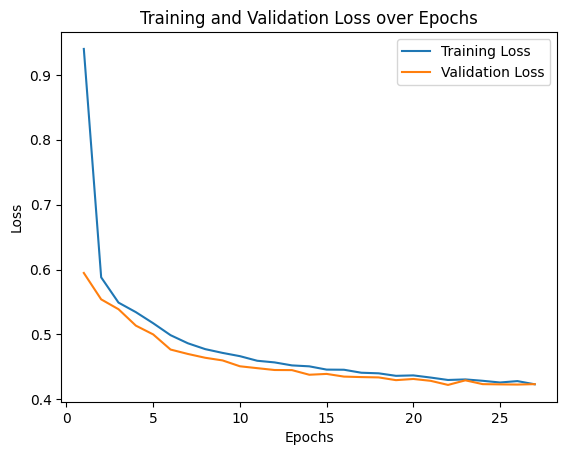

In [22]:
visualize_loss(baseline_loss)

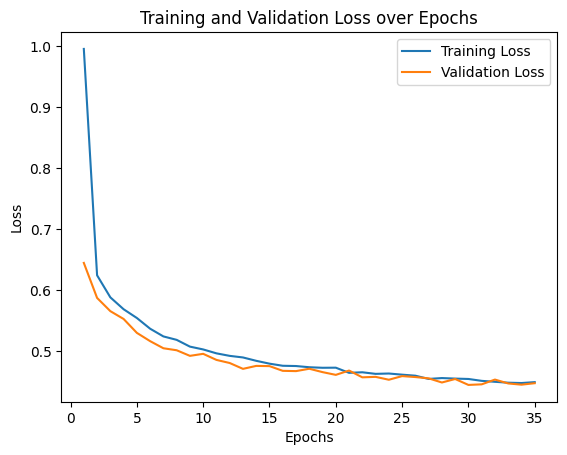

In [23]:
visualize_loss(edit_aware_loss)

In [24]:
total_cost, stats, edit_sample_costs = evaluate_model(edit_aware_model, test_dataloader)
print(f"Total edit cost on test set: {total_cost}")
print(f"Edit statistics: {dict(stats)}")

Total edit cost on test set: 52077
Edit statistics: {'insert': 9133, 'delete': 7882, 'replace_pitch': 24414, 'replace_duration': 10648}


In [28]:
total_cost, stats, edit_sample_costs = evaluate_model(edit_aware_model, test_dataloader)
print(f"Total edit cost on test set: {total_cost}")
print(f"Edit statistics: {dict(stats)}")

Total edit cost on test set: 50845
Edit statistics: {'insert': 9479, 'delete': 6740, 'replace_pitch': 23479, 'replace_duration': 11147}


In [25]:
total_cost, stats, baseline_sample_costs = evaluate_model(model, test_dataloader)
print(f"Total edit cost on test set: {total_cost}")
print(f"Edit statistics: {dict(stats)}")

Total edit cost on test set: 48878
Edit statistics: {'insert': 9229, 'delete': 6464, 'replace_pitch': 23027, 'replace_duration': 10158}


In [28]:
improvement = paired_edit_improvement(baseline_sample_costs, edit_sample_costs)
cost_per_note = compare_cost_per_note(baseline_sample_costs, edit_sample_costs)

print("\nPaired Edit Improvement:", improvement)
print("\nCost Per Note:", cost_per_note)


Paired Edit Improvement: {'mean_delta': -0.032036613272311214, 'median_delta': 0.0, 'std_delta': 2.9440050738899335, 'pct_improved': 40.73226544622426, 'pct_worse': 40.274599542334094, 'pct_equal': 18.993135011441648, 'baseline_mean_cost': 1.7735316660562903, 'editaware_mean_cost': 1.7894893595993446}

Cost Per Note: {'baseline_mean': 0.13287568909198538, 'editaware_mean': 0.13275446290578338, 'mean_delta': 0.00012122618620198635, 'median_delta': 0.0, 'pct_improved': 40.73226544622426}
